# Explaining County-Level Changes in Vote Totals Between the 2020 and 2024 U.S. Presidential Elections

### A Civic Data Science Analysis Using County Election Returns and County Health Rankings Data

This project examines changes in county-level presidential vote totals between the 2020 and 2024 U.S. presidential elections.

The goal is to answer:

> Which counties experienced the largest changes in vote totals between 2020 and 2024, and what county characteristics are associated with those changes?

This project is designed as an applied civic-data analysis. The emphasis is on careful data cleaning, clear reporting, and accessible insights for non-technical stakeholders such as civic organizations, election administrators, and policy researchers.

**Important note:** This analysis uses total presidential votes cast as a proxy for voter participation. Vote totals are not the same as turnout rates because they do not account for voting-age population or voting-eligible population.

## Executive Summary

This notebook analyzes county-level changes in presidential vote totals between the 2020 and 2024 U.S. presidential elections.

The analysis combines:

1. **MIT Election Data and Science Lab county presidential election returns**
2. **2024 County Health Rankings county-level socioeconomic and demographic data**

The project focuses on identifying counties with the largest increases and decreases in total votes cast, comparing raw and percentage vote changes, exploring relationships between county characteristics and vote total change, and producing clear findings and open questions for further investigation.

This analysis identifies associations, not causal relationships.

## Notebook Index

1. Load and inspect data
2. Clean MIT county election returns
3. Calculate 2020–2024 vote total change
4. Summarize national and county-level patterns
5. Identify counties with the largest raw and percentage changes
6. Clean and select County Health Rankings variables
7. Merge election changes with county characteristics
8. Explore correlations and visual relationships
9. Build an interpretable regression model
10. Summarize findings, limitations, and questions for election administrators

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


## Data Sources

This project uses two public datasets:

1. **MIT Election Data and Science Lab County Presidential Returns, 2000–2024**
   - Used to examine county-level presidential election results.

2. **County Health Rankings Analytic Data, 2020 and 2024**
   - Used to examine county level social, economic, demographic, and civic participation variables.

The analysis begins with 2024 voter turnout and then expands to compare turnout patterns between 2020 and 2024.

In [3]:
base_path = "/content/drive/MyDrive/Explaining County-Level Voting Shifts in the 2024 U.S. Election"

election_path = base_path + "/Election Data/countypres_2000-2024.tab"
chr2024_path = base_path + "/Census Data/analytic_data2024.csv"

In [4]:
mit_df = pd.read_csv(election_path, sep="\t")
chr2024 = pd.read_csv(chr2024_path, low_memory=False)

print("MIT Election Data shape:", mit_df.shape)
print("County Health Rankings 2024 shape:", chr2024.shape)

MIT Election Data shape: (94151, 12)
County Health Rankings 2024 shape: (3196, 770)


# Inspect MIT Election Data

The MIT election file contains one row per candidate per county per election year. To analyze county-level vote totals, we need one row per county per year.

The key fields are

* county_fips,
* year
* state
* state_po
* county_name
* candidate
* party
* candidatevotes
* totalvotes

In [5]:
print("MIT Election Data:", mit_df.shape)


MIT Election Data: (94151, 12)


In [6]:
mit_df.head()

,state,county_name,year,state_po,county_fips,office,candidate,party,candidatevotes,totalvotes,version,mode
0,ALABAMA,AUTAUGA,2024,AL,1001.0,US PRESIDENT,OTHER,OTHER,293.0,28281,20260225,TOTAL
1,ALABAMA,AUTAUGA,2024,AL,1001.0,US PRESIDENT,CHASE OLIVER,LIBERTARIAN,65.0,28281,20260225,TOTAL
2,ALABAMA,AUTAUGA,2024,AL,1001.0,US PRESIDENT,KAMALA D HARRIS,DEMOCRAT,7439.0,28281,20260225,TOTAL
3,ALABAMA,AUTAUGA,2024,AL,1001.0,US PRESIDENT,DONALD J TRUMP,REPUBLICAN,20484.0,28281,20260225,TOTAL
4,ALABAMA,BALDWIN,2024,AL,1003.0,US PRESIDENT,OTHER,OTHER,1276.0,122249,20260225,TOTAL


In [7]:
mit_df.columns.tolist()

['state',
 'county_name',
 'year',
 'state_po',
 'county_fips',
 'office',
 'candidate',
 'party',
 'candidatevotes',
 'totalvotes',
 'version',
 'mode']

In [8]:
mit_df[
    ['state', 'county_name', 'year', 'county_fips', 'candidate', 'party', 'candidatevotes', 'totalvotes']
].head(10)

,state,county_name,year,county_fips,candidate,party,candidatevotes,totalvotes
0,ALABAMA,AUTAUGA,2024,1001.0,OTHER,OTHER,293.0,28281
1,ALABAMA,AUTAUGA,2024,1001.0,CHASE OLIVER,LIBERTARIAN,65.0,28281
2,ALABAMA,AUTAUGA,2024,1001.0,KAMALA D HARRIS,DEMOCRAT,7439.0,28281
3,ALABAMA,AUTAUGA,2024,1001.0,DONALD J TRUMP,REPUBLICAN,20484.0,28281
4,ALABAMA,BALDWIN,2024,1003.0,OTHER,OTHER,1276.0,122249
5,ALABAMA,BALDWIN,2024,1003.0,DONALD J TRUMP,REPUBLICAN,95798.0,122249
6,ALABAMA,BALDWIN,2024,1003.0,KAMALA D HARRIS,DEMOCRAT,24934.0,122249
7,ALABAMA,BALDWIN,2024,1003.0,CHASE OLIVER,LIBERTARIAN,241.0,122249
8,ALABAMA,BARBOUR,2024,1005.0,DONALD J TRUMP,REPUBLICAN,5606.0,9855
9,ALABAMA,BARBOUR,2024,1005.0,KAMALA D HARRIS,DEMOCRAT,4158.0,9855


In [9]:
mit_df['year'].value_counts().sort_index()

,count
year,
2000,12628
2004,9474
2008,9474
2012,9474
2016,9474
2020,22093
2024,21534


# Inspect County Health Rankings Analytic Data

In [10]:
print("County Health Rankings 2024 shape:", chr2024.shape)

County Health Rankings 2024 shape: (3196, 770)


In [11]:
chr2024.columns.tolist()

['State FIPS Code',
 'County FIPS Code',
 '5-digit FIPS Code',
 'State Abbreviation',
 'Name',
 'Release Year',
 'County Clustered (Yes=1/No=0)',
 'Premature Death raw value',
 'Premature Death numerator',
 'Premature Death denominator',
 'Premature Death CI low',
 'Premature Death CI high',
 'Premature Death flag (0 = No Flag/1=Unreliable/2=Suppressed)',
 'Premature Death (AIAN)',
 'Premature Death CI low (AIAN)',
 'Premature Death CI high (AIAN)',
 'Premature Death flag (AIAN) (. = No Flag/1=Unreliable/2=Suppressed)',
 'Premature Death (Asian/Pacific Islander)',
 'Premature Death CI low (Asian/Pacific Islander)',
 'Premature Death CI high (Asian/Pacific Islander)',
 'Premature Death flag (Asian/Pacific Islander) (. = No Flag/1=Unreliable/2=Suppressed)',
 'Premature Death (Black)',
 'Premature Death CI low (Black)',
 'Premature Death CI high (Black)',
 'Premature Death flag (Black) (. = No Flag/1=Unreliable/2=Suppressed)',
 'Premature Death (Hispanic)',
 'Premature Death CI low (Hispa

# 3. County-Level Vote Totals for 2020 and 2024

Because totalvotes repeats across candidate rows within the same county-year, this section aggregates the MIT data to one row per county per year.

We use the maximum value of totalvotes within each county year because the same county level total is repeated across candidate rows.

In [12]:
county_votes = (
    mit_df
    .dropna(subset=['county_fips'])
    .groupby(['county_fips', 'year'])
    .agg(
        state=('state', 'first'),
        state_po=('state_po', 'first'),
        county_name=('county_name', 'first'),
        totalvotes=('totalvotes', 'max')
    )
    .reset_index()
)

county_votes.head()

,county_fips,year,state,state_po,county_name,totalvotes
0,1001.0,2000,ALABAMA,AL,AUTAUGA,17208
1,1001.0,2004,ALABAMA,AL,AUTAUGA,20081
2,1001.0,2008,ALABAMA,AL,AUTAUGA,23641
3,1001.0,2012,ALABAMA,AL,AUTAUGA,23932
4,1001.0,2016,ALABAMA,AL,AUTAUGA,24973


In [13]:
county_votes_2020_2024 = (
    county_votes[
        county_votes['year'].isin([2020, 2024])
    ]
    .copy()
)

county_votes_2020_2024.head()

,county_fips,year,state,state_po,county_name,totalvotes
5,1001.0,2020,ALABAMA,AL,AUTAUGA,27770
6,1001.0,2024,ALABAMA,AL,AUTAUGA,28281
12,1003.0,2020,ALABAMA,AL,BALDWIN,109679
13,1003.0,2024,ALABAMA,AL,BALDWIN,122249
19,1005.0,2020,ALABAMA,AL,BARBOUR,10518


## Create One Row Per County

This section pivots 2020 and 2024 vote totals into separate columns while preserving county and state names.

The county lookup table is grouped by county_fips to ensure there is only one row per county before merging. This prevents duplicate rows from being introduced.

In [14]:
votes_wide = (
    county_votes_2020_2024
    .pivot(
        index='county_fips',
        columns='year',
        values='totalvotes'
    )
    .reset_index()
)

votes_wide = votes_wide.rename(
    columns={
        2020: 'votes_2020',
        2024: 'votes_2024'
    }
)

# Remove the column index name left over from pivot
votes_wide.columns.name = None

# Format FIPS as a 5-digit string
votes_wide['county_fips'] = (
    votes_wide['county_fips']
    .astype(int)
    .astype(str)
    .str.zfill(5)
)

# Build a duplicate-safe county lookup table
county_lookup = (
    county_votes_2020_2024
    .groupby('county_fips')
    .agg(
        county_name=('county_name', 'first'),
        state=('state', 'first'),
        state_po=('state_po', 'first')
    )
    .reset_index()
)

county_lookup['county_fips'] = (
    county_lookup['county_fips']
    .astype(int)
    .astype(str)
    .str.zfill(5)
)

votes_wide = votes_wide.merge(
    county_lookup,
    on='county_fips',
    how='left'
)

votes_wide = votes_wide[
    [
        'county_fips',
        'county_name',
        'state',
        'state_po',
        'votes_2020',
        'votes_2024'
    ]
]

votes_wide.head()

,county_fips,county_name,state,state_po,votes_2020,votes_2024
0,01001,AUTAUGA,ALABAMA,AL,27770.0,28281.0
1,01003,BALDWIN,ALABAMA,AL,109679.0,122249.0
2,01005,BARBOUR,ALABAMA,AL,10518.0,9855.0
3,01007,BIBB,ALABAMA,AL,9595.0,9257.0
4,01009,BLOUNT,ALABAMA,AL,27588.0,28163.0


## Duplicate Check

There should be zero duplicate FIPS codes in votes_wide.

In [15]:
print("Rows:", len(votes_wide))
print("Duplicate county FIPS codes:", votes_wide['county_fips'].duplicated().sum())

Rows: 3156
Duplicate county FIPS codes: 0


4. Calculate Vote Total Change
This project uses total presidential votes cast in each county as a proxy for voter participation.

Two change measures are calculated:

Raw vote change: 2024 votes minus 2020 votes
Percent vote change: raw change divided by 2020 votes
Percent change is useful for comparing counties of different sizes, but it can exaggerate changes in very small counties. Both measures should be interpreted together.

In [16]:
votes_wide['vote_change_2020_2024'] = (
    votes_wide['votes_2024'] - votes_wide['votes_2020']
)

votes_wide['pct_change_2020_2024'] = (
    votes_wide['vote_change_2020_2024'] / votes_wide['votes_2020']
)

votes_wide.head()

,county_fips,county_name,state,state_po,votes_2020,votes_2024,vote_change_2020_2024,pct_change_2020_2024
0,01001,AUTAUGA,ALABAMA,AL,27770.0,28281.0,511.0,0.018401
1,01003,BALDWIN,ALABAMA,AL,109679.0,122249.0,12570.0,0.114607
2,01005,BARBOUR,ALABAMA,AL,10518.0,9855.0,-663.0,-0.063035
3,01007,BIBB,ALABAMA,AL,9595.0,9257.0,-338.0,-0.035227
4,01009,BLOUNT,ALABAMA,AL,27588.0,28163.0,575.0,0.020842


# 5. Exploring 2020–2024 Vote Total Change

## Summary Interpretation

The summary table provides two different views of county level vote totals. The first table gives a plain-language overview for readers, while the second table provides more detailed descriptive statistics.

The count row in the detailed summary refers to the number of county observations, not the number of voters. The total number of votes cast nationally is shown in the executive summary table.

In [17]:
summary = pd.DataFrame({
    "Metric": [
        "Number of Counties",
        "Total Votes Cast (2020)",
        "Total Votes Cast (2024)",
        "Average County Votes (2020)",
        "Average County Votes (2024)",
        "Average Vote Change",
        "Average Percent Change"
    ],
    "Value": [
        f"{len(votes_wide):,}",
        f"{votes_wide['votes_2020'].sum():,.0f}",
        f"{votes_wide['votes_2024'].sum():,.0f}",
        f"{votes_wide['votes_2020'].mean():,.0f}",
        f"{votes_wide['votes_2024'].mean():,.0f}",
        f"{votes_wide['vote_change_2020_2024'].mean():,.0f}",
        f"{votes_wide['pct_change_2020_2024'].mean():.2%}"
    ]
})

summary

,Metric,Value
0,Number of Counties,"3,156"
1,Total Votes Cast (2020),"158,476,336"
2,Total Votes Cast (2024),"155,209,552"
3,Average County Votes (2020),"50,246"
4,Average County Votes (2024),"49,210"
5,Average Vote Change,"-1,032"
6,Average Percent Change,-0.81%


In [18]:
summary_stats = votes_wide[
    [
        'votes_2020',
        'votes_2024',
        'vote_change_2020_2024',
        'pct_change_2020_2024'
    ]
].describe()

summary_stats.style.format({
    'votes_2020': '{:,.0f}',
    'votes_2024': '{:,.0f}',
    'vote_change_2020_2024': '{:,.0f}',
    'pct_change_2020_2024': '{:.2%}'
})

,votes_2020,votes_2024,vote_change_2020_2024,pct_change_2020_2024
count,"3,154","3,154","3,152",315200.00%
mean,"50,246","49,210","-1,032",-0.81%
std,"149,331","139,489","13,142",6.43%
min,66,97,"-535,938",-43.57%
25%,"5,426","5,271",-423,-4.30%
50%,"12,328","12,286",-52,-1.02%
75%,"33,328","33,758",387,2.55%
max,"4,264,365","3,728,427","58,915",67.17%


## Distribution Interpretation

**Interpretation**

The distribution of county-level vote total changes between 2020 and 2024 is concentrated around zero, indicating that most counties experienced relatively modest changes in the total number of votes cast. The peak of the distribution falls slightly below zero, suggesting that more counties experienced small decreases rather than increases in vote totals.

The distribution is approximately bell-shaped but exhibits noticeable tails on both sides. This indicates that while most counties saw limited change, a small number of counties experienced unusually large increases or decreases in voting activity. These outlier counties may reflect population shifts, migration patterns, changes in voter participation, election administration differences, or local political dynamics.

Overall, the histogram suggests that the national decline in total votes cast between 2020 and 2024 was broadly distributed across many counties rather than being driven by only a few extreme cases.

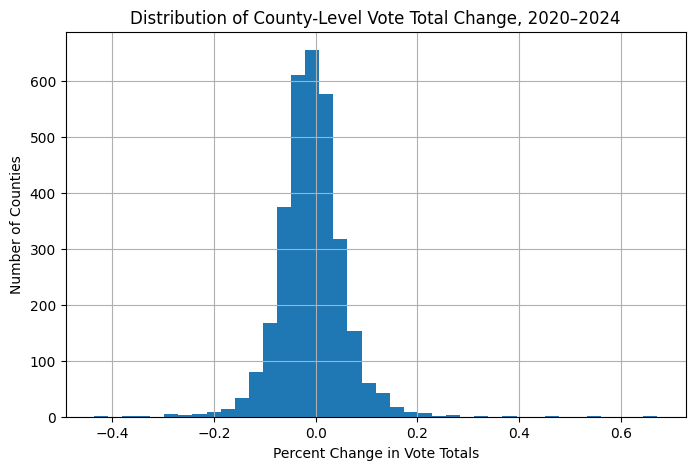

In [19]:
plt.figure(figsize=(8, 5))

votes_wide['pct_change_2020_2024']\
    .replace([np.inf, -np.inf], np.nan)\
    .dropna()\
    .hist(bins=40)

plt.title("Distribution of County-Level Vote Total Change, 2020–2024")
plt.xlabel("Percent Change in Vote Totals")
plt.ylabel("Number of Counties")
plt.show()

# 6. Counties with the Largest Percentage Increases

**Interpretation**

The counties with the largest percentage increases in vote totals were primarily smaller counties and Alaska legislative districts, where relatively modest increases in the number of votes cast produced substantial percentage changes.

For example, Loving County, Texas increased from 66 votes in 2020 to 97 votes in 2024, producing a large percentage increase despite adding only 31 votes. Similar patterns appear among several Alaska districts, where baseline vote totals were relatively low.

Some larger-growth counties also appear on the list, including Brunswick County, North Carolina, Kaufman County, Texas, and Jackson County, Georgia. Unlike the smallest counties, these jurisdictions experienced both substantial percentage increases and meaningful gains in raw vote totals, suggesting that population growth or increased electoral participation may have played a larger role.

These findings highlight why percentage change should be interpreted alongside raw vote change. Percentage measures are useful for comparing counties of different sizes but can exaggerate changes in counties with very small voting populations.

In [20]:
counties_with_the_largest_percentage_increases = (
    votes_wide
    .sort_values('pct_change_2020_2024', ascending=False)
    [[
        'county_name',
        'state',
        'votes_2020',
        'votes_2024',
        'vote_change_2020_2024',
        'pct_change_2020_2024'
    ]]
    .head(15)
)

counties_with_the_largest_percentage_increases.style.format({
    'votes_2020': '{:,.0f}',
    'votes_2024': '{:,.0f}',
    'vote_change_2020_2024': '{:,.0f}',
    'pct_change_2020_2024': '{:.2%}'
})

,county_name,state,votes_2020,votes_2024,vote_change_2020_2024,pct_change_2020_2024
81,DISTRICT 15,ALASKA,"5,559","9,293","3,734",67.17%
68,DISTRICT 2,ALASKA,"6,136","9,563","3,427",55.85%
2686,LOVING,TEXAS,66,97,31,46.97%
89,DISTRICT 23,ALASKA,"7,739","10,685","2,946",38.07%
69,DISTRICT 3,ALASKA,"8,385","11,107","2,722",32.46%
72,DISTRICT 6,ALASKA,"9,460","12,000","2,540",26.85%
2354,JASPER,SOUTH CAROLINA,"14,394","18,227","3,833",26.63%
2788,ZAPATA,TEXAS,"3,874","4,871",997,25.74%
476,JACKSON,GEORGIA,"37,670","47,243","9,573",25.41%
489,LONG,GEORGIA,"5,656","7,056","1,400",24.75%


# 7. Largest Raw Vote Increases

**Interpretation**

The counties with the largest raw increases in vote totals were concentrated in rapidly growing metropolitan and suburban regions across the United States.

Clark County, Nevada recorded the largest increase, adding nearly 59,000 votes between 2020 and 2024. Several Texas counties—including Montgomery, Denton, Collin, and Williamson—also appear among the largest increases, reflecting continued population growth in the Dallas-Fort Worth and Austin metropolitan areas.

Other high-growth counties include Pinal County, Arizona; Wake County, North Carolina; Dane County, Wisconsin; and St. Johns County, Florida. These counties have experienced significant residential growth over the past decade and continue to attract new residents.

Unlike percentage-based rankings, raw vote changes highlight where the greatest number of additional votes were added nationally. As a result, these results may better capture the electoral impact of population growth and migration patterns in large counties.

In [21]:
largest_raw_vote_increases = (
    votes_wide
    .sort_values('vote_change_2020_2024', ascending=False)
    [[
        'county_name',
        'state',
        'votes_2020',
        'votes_2024',
        'vote_change_2020_2024',
        'pct_change_2020_2024'
    ]]
    .head(15)
)

largest_raw_vote_increases.style.format({
    'votes_2020': '{:,.0f}',
    'votes_2024': '{:,.0f}',
    'vote_change_2020_2024': '{:,.0f}',
    'pct_change_2020_2024': '{:.2%}'
})

,county_name,state,votes_2020,votes_2024,vote_change_2020_2024,pct_change_2020_2024
1759,CLARK,NEVADA,"972,308","1,031,223","58,915",6.06%
2705,MONTGOMERY,TEXAS,"271,543","307,258","35,715",13.15%
2596,DENTON,TEXAS,"417,964","449,188","31,224",7.47%
119,PINAL,ARIZONA,"184,974","211,595","26,621",14.39%
2353,HORRY,SOUTH CAROLINA,"179,744","205,954","26,210",14.58%
2578,COLLIN,TEXAS,"490,856","515,585","24,729",5.04%
1993,WAKE,NORTH CAROLINA,"631,830","653,580","21,750",3.44%
3072,DANE,WISCONSIN,"344,791","365,929","21,138",6.13%
386,ST. JOHNS,FLORIDA,"176,622","197,457","20,835",11.80%
1911,BRUNSWICK,NORTH CAROLINA,"90,175","109,378","19,203",21.30%


# 8. Counties with the Largest Percentage Decreases

The largest percentage declines were concentrated among Alaska legislative districts and several small rural counties in Mississippi, Louisiana, and Texas.

Many of these counties experienced relatively modest declines in the actual number of votes cast, but because their voting populations were small to begin with, those declines translated into substantial percentage decreases.

For example, District 31 in Alaska lost approximately 5,400 votes, representing one of the largest percentage declines in the dataset. Similar patterns appear throughout several other Alaska districts.

These results should be interpreted cautiously because percentage changes can be heavily influenced by the size of a county's voting population. A decline of several hundred or several thousand votes can appear much larger in percentage terms when the baseline vote total is relatively small.

In [22]:
counties_with_the_largest_percentage_decreases = (
    votes_wide
    .sort_values('pct_change_2020_2024', ascending=True)
    [[
        'county_name',
        'state',
        'votes_2020',
        'votes_2024',
        'vote_change_2020_2024',
        'pct_change_2020_2024'
    ]]
    .head(15)
)

counties_with_the_largest_percentage_decreases.style.format({
    'votes_2020': '{:,.0f}',
    'votes_2024': '{:,.0f}',
    'vote_change_2020_2024': '{:,.0f}',
    'pct_change_2020_2024': '{:.2%}'
})

,county_name,state,votes_2020,votes_2024,vote_change_2020_2024,pct_change_2020_2024
97,DISTRICT 31,ALASKA,"12,410","7,003","-5,407",-43.57%
88,DISTRICT 22,ALASKA,"9,520","5,463","-4,057",-42.62%
84,DISTRICT 18,ALASKA,"7,720","4,816","-2,904",-37.62%
80,DISTRICT 14,ALASKA,"11,443","7,426","-4,017",-35.10%
98,DISTRICT 32,ALASKA,"8,335","5,864","-2,471",-29.65%
1490,WILKINSON,MISSISSIPPI,"4,127","2,931","-1,196",-28.98%
105,DISTRICT 39,ALASKA,"5,891","4,206","-1,685",-28.60%
106,DISTRICT 40,ALASKA,"4,603","3,293","-1,310",-28.46%
94,DISTRICT 28,ALASKA,"12,749","9,279","-3,470",-27.22%
1483,TUNICA,MISSISSIPPI,"3,562","2,668",-894,-25.10%


# 9. Largest Raw Vote Decreases
**Interpretation**

The counties with the largest raw declines were overwhelmingly concentrated in large urban counties.

Los Angeles County recorded the largest decline, losing more than 535,000 votes between 2020 and 2024. Other major decreases occurred in Cook County, Illinois; Orange County, California; San Diego County, California; Santa Clara County, California; and Harris County, Texas.

Many of these counties were among the highest-turnout jurisdictions in the nation during the 2020 election. Because 2020 was an unusually high-turnout election nationally, some decline in 2024 may reflect a return toward more typical participation levels rather than a structural decrease in voter engagement.

The concentration of large raw declines in major metropolitan counties suggests that national vote decreases were driven primarily by reductions in turnout within densely populated urban areas rather than widespread declines across rural America.

In [23]:
largest_raw_vote_decreases = (
    votes_wide
    .sort_values('vote_change_2020_2024', ascending=True)
    [[
        'county_name',
        'state',
        'votes_2020',
        'votes_2024',
        'vote_change_2020_2024',
        'pct_change_2020_2024'
    ]]
    .head(15)
)

largest_raw_vote_decreases.style.format({
    'votes_2020': '{:,.0f}',
    'votes_2024': '{:,.0f}',
    'vote_change_2020_2024': '{:,.0f}',
    'pct_change_2020_2024': '{:.2%}'
})

,county_name,state,votes_2020,votes_2024,vote_change_2020_2024,pct_change_2020_2024
216,LOS ANGELES,CALIFORNIA,"4,264,365","3,728,427","-535,938",-12.57%
621,COOK,ILLINOIS,"2,321,486","2,079,239","-242,247",-10.43%
227,ORANGE,CALIFORNIA,"1,522,113","1,390,965","-131,148",-8.62%
234,SAN DIEGO,CALIFORNIA,"1,602,143","1,477,786","-124,357",-7.76%
240,SANTA CLARA,CALIFORNIA,"850,741","750,433","-100,308",-11.79%
198,ALAMEDA,CALIFORNIA,"770,070","669,907","-100,163",-13.01%
2636,HARRIS,TEXAS,"1,640,818","1,557,484","-83,334",-5.08%
337,BROWARD,FLORIDA,"957,672","874,539","-83,133",-8.68%
1880,QUEENS,NEW YORK,"794,498","712,191","-82,307",-10.36%
2982,KING,WASHINGTON,"1,210,507","1,130,502","-80,005",-6.61%


# 10. County Characteristics

This section selects a focused set of county-level variables from County Health Rankings.

Variables were selected to represent:

- **Education:** High School Completion, Some College
- **Economic Conditions:** Median Household Income, Children in Poverty
- **Community Stability:** Homeownership
- **Civic Access and Geography:** Broadband Access, Percent Rural
- **Demographics:** Percent Age 65 and Older
- **County Size:** Population

These variables were selected because they may influence a resident's ability, opportunity, or motivation to participate in elections.

Population was included to account for differences in county size, since larger counties naturally tend to have more voters than smaller counties.

In [24]:
analysis_cols = [
    '5-digit FIPS Code',
    'Name',
    'State Abbreviation',

    'High School Completion raw value',
    'Some College raw value',

    'Median Household Income raw value',
    'Children in Poverty raw value',

    'Homeownership raw value',

    'Broadband Access raw value',
    '% Rural raw value',

    '% 65 and Older raw value',

    'Population raw value'
]

chr2024_small = chr2024[analysis_cols].copy()

chr2024_small.head()

,5-digit FIPS Code,Name,State Abbreviation,High School Completion raw value,Some College raw value,Median Household Income raw value,Children in Poverty raw value,Homeownership raw value,Broadband Access raw value,% Rural raw value,% 65 and Older raw value,Population raw value
0,fipscode,county,state,v168_rawvalue,v069_rawvalue,v063_rawvalue,v024_rawvalue,v153_rawvalue,v166_rawvalue,v058_rawvalue,v053_rawvalue,v051_rawvalue
1,00000,United States,US,0.8914404664,0.6758297804,74755,0.163,0.6481638608,0.8834669636,0.2000313707,0.17340837,333287557
2,01000,Alabama,AL,0.8771539906,0.6160416166,59703,0.218,0.6971999069,0.8378641078,0.4226276049,0.1802679623,5074296
3,01001,Autauga County,AL,0.9040260774,0.6414750147,70148,0.157,0.7545275238,0.8906670253,0.406768132,0.1641091718,59759
4,01003,Baldwin County,AL,0.9159931027,0.6568041849,71704,0.161,0.7787053149,0.8892094888,0.3758645536,0.2192870331,246435


In [25]:
numeric_cols = [
    'High School Completion raw value',
    'Some College raw value',
    'Median Household Income raw value',
    'Children in Poverty raw value',
    'Homeownership raw value',
    'Broadband Access raw value',
    '% Rural raw value',
    '% 65 and Older raw value',
    'Population raw value'
]

chr2024_small[numeric_cols] = chr2024_small[numeric_cols].apply(
    pd.to_numeric,
    errors='coerce'
)

## Remove National and State Summary Rows

County Health Rankings includes U.S. and state summary rows. This analysis focuses only on county-level observations.

In [26]:
chr2024_counties = chr2024_small[
    chr2024_small['5-digit FIPS Code'].str[2:] != '000'
].copy()

chr2024_counties['5-digit FIPS Code'] = (
    chr2024_counties['5-digit FIPS Code']
    .astype(str)
    .str.zfill(5)
)

chr2024_counties.shape

(3144, 12)

In [27]:
chr2024_counties.isnull().sum().sort_values(ascending=False)

,0
Children in Poverty raw value,2
Median Household Income raw value,2
High School Completion raw value,1
Some College raw value,1
Broadband Access raw value,1
% Rural raw value,1
% 65 and Older raw value,1
Homeownership raw value,1
Population raw value,1
State Abbreviation,0


In [28]:
chr2024_counties[numeric_cols].describe()

,High School Completion raw value,Some College raw value,Median Household Income raw value,Children in Poverty raw value,Homeownership raw value,Broadband Access raw value,% Rural raw value,% 65 and Older raw value,Population raw value
count,3143.000000,3143.000000,3142.000000,3142.000000,3143.000000,3143.000000,3143.000000,3143.000000,3.143000e+03
mean,0.883548,0.588776,63267.724698,0.194286,0.727143,0.824437,0.640782,0.204996,1.060347e+05
std,0.057201,0.118524,16275.491415,0.083986,0.086098,0.072242,0.336024,0.048691,3.325840e+05
min,0.333333,0.117647,28972.000000,0.024000,0.000000,0.359694,0.000000,0.054428,5.100000e+01
25%,0.852752,0.509342,52471.750000,0.134000,0.683699,0.786588,0.358030,0.173737,1.076350e+04
50%,0.895558,0.589880,60820.500000,0.181000,0.740403,0.834887,0.666659,0.201293,2.594000e+04
75%,0.925427,0.672343,70586.500000,0.241000,0.784772,0.874261,1.000000,0.231358,6.889250e+04
max,0.996904,1.000000,167605.000000,0.887000,0.969858,1.000000,1.000000,0.574546,9.721138e+06


# 11. Merge Election Change with County Characteristics

In [29]:
analysis_df = chr2024_counties.merge(
    votes_wide,
    left_on='5-digit FIPS Code',
    right_on='county_fips',
    how='inner'
)

analysis_df.shape

(3115, 20)

In [30]:
analysis_df[
    [
        'Name',
        'State Abbreviation',
        'votes_2020',
        'votes_2024',
        'vote_change_2020_2024',
        'pct_change_2020_2024'
    ]
].head()

,Name,State Abbreviation,votes_2020,votes_2024,vote_change_2020_2024,pct_change_2020_2024
0,Autauga County,AL,27770.0,28281.0,511.0,0.018401
1,Baldwin County,AL,109679.0,122249.0,12570.0,0.114607
2,Barbour County,AL,10518.0,9855.0,-663.0,-0.063035
3,Bibb County,AL,9595.0,9257.0,-338.0,-0.035227
4,Blount County,AL,27588.0,28163.0,575.0,0.020842


## Check Missing Values After Merge

In [31]:
model_cols = numeric_cols + ['vote_change_2020_2024', 'pct_change_2020_2024']

analysis_df[model_cols].isnull().sum().sort_values(ascending=False)

,0
vote_change_2020_2024,1
pct_change_2020_2024,1
High School Completion raw value,0
Median Household Income raw value,0
Some College raw value,0
Children in Poverty raw value,0
Homeownership raw value,0
% Rural raw value,0
Broadband Access raw value,0
Population raw value,0


# 12. Correlation Analysis

This section examines which county characteristics are correlated with changes in vote totals between 2020 and 2024.

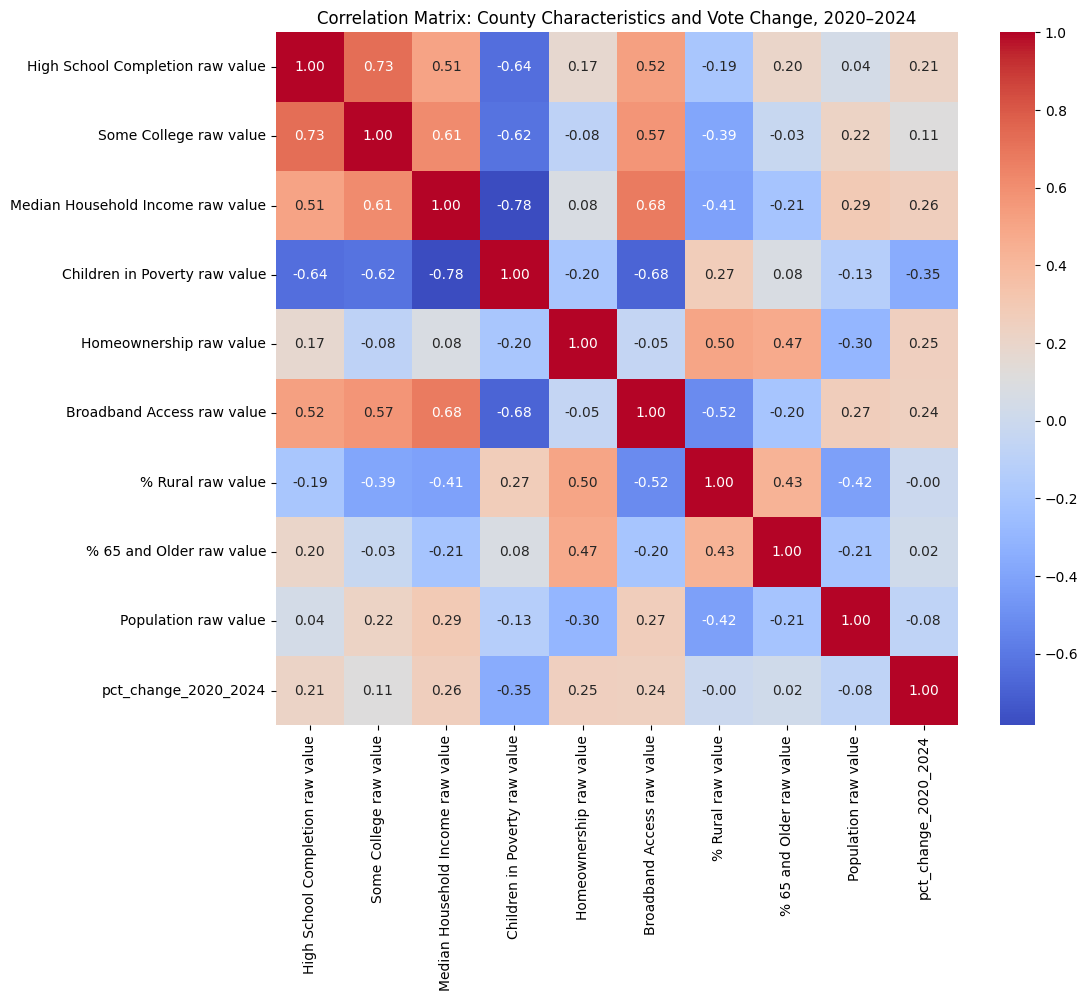

In [32]:
corr_cols = numeric_cols + ['pct_change_2020_2024']

corr_df = analysis_df[corr_cols].replace([np.inf, -np.inf], np.nan)

plt.figure(figsize=(11, 9))
sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Matrix: County Characteristics and Vote Change, 2020–2024")
plt.show()

## Top Correlations with Percent Vote Change

In [33]:
corrs = (
    analysis_df[
        numeric_cols + ['pct_change_2020_2024']
    ]
    .replace([np.inf, -np.inf], np.nan)
    .corr()['pct_change_2020_2024']
    .sort_values(ascending=False)
)

corrs

,pct_change_2020_2024
pct_change_2020_2024,1.000000
Median Household Income raw value,0.258096
Homeownership raw value,0.251423
Broadband Access raw value,0.244090
High School Completion raw value,0.214675
Some College raw value,0.111227
% 65 and Older raw value,0.019863
% Rural raw value,-0.003850
Population raw value,-0.079454
Children in Poverty raw value,-0.353820


# Correlation Matrix
**Interpretation**

The correlation matrix provides an initial look at the relationship between county characteristics and changes in vote totals between 2020 and 2024.

Several variables show positive associations with vote growth, including:

* Median Household Income
* Homeownership
* Broadband Access
* High School Completion

Counties with higher values on these measures tended to experience larger increases—or smaller declines—in vote totals.

The strongest negative relationship appears for Children in Poverty (-0.35). Counties with higher levels of child poverty generally experienced larger declines in vote totals.

Several variables show surprisingly weak relationships. Rurality exhibits almost no relationship with vote change (-0.004), while the percentage of residents age 65 and older shows virtually no association (0.02). Population also shows only a small negative relationship (-0.08).

It is important to note that many predictor variables are correlated with one another. For example, income, education, homeownership, and broadband access tend to move together. As a result, correlations should be viewed as exploratory indicators rather than evidence of causal effects.

# 13. Visualize Key Relationships

# Some College vs. Vote Change Scatter Plot
I**nterpretation**

The relationship between educational attainment and vote change appears positive but relatively weak.

The fitted regression line slopes upward, indicating that counties with a larger share of residents who attended college generally experienced slightly stronger growth in vote totals between 2020 and 2024.

However, the substantial vertical spread of the data points demonstrates that educational attainment alone explains only a small portion of the variation in vote change. Counties with similar educational profiles often experienced very different voting outcomes.

This suggests that while education may contribute to differences in electoral participation, many additional factors influence county-level vote totals.

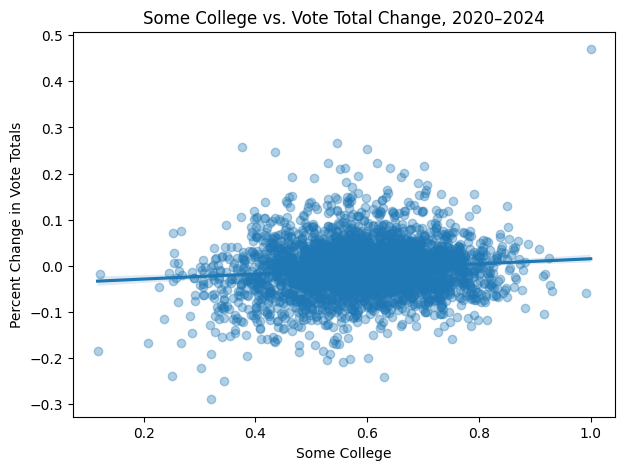

In [34]:
plt.figure(figsize=(7, 5))
sns.regplot(
    data=analysis_df,
    x='Some College raw value',
    y='pct_change_2020_2024',
    scatter_kws={'alpha': 0.35}
)
plt.title("Some College vs. Vote Total Change, 2020–2024")
plt.xlabel("Some College")
plt.ylabel("Percent Change in Vote Totals")
plt.show()

# Median Household Income vs. Vote Change Scatter Plot
**Interpretation**

Median household income exhibits one of the strongest positive relationships with vote change in the dataset.

The upward trend suggests that wealthier counties were more likely to experience increases in vote totals or smaller declines between 2020 and 2024. This pattern is consistent with the positive correlation observed earlier.

Nevertheless, the relationship remains moderate rather than deterministic. Many high-income counties experienced declines, while some lower-income counties experienced growth.

Income appears to be an important indicator of county-level voting trends, but it should not be interpreted as a direct cause of electoral participation changes.

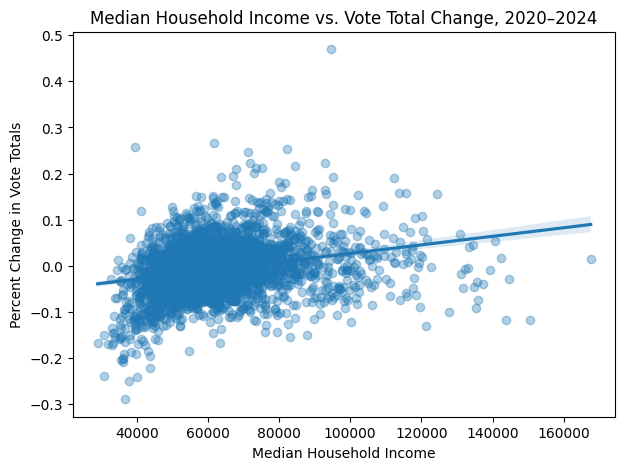

In [35]:
plt.figure(figsize=(7, 5))
sns.regplot(
    data=analysis_df,
    x='Median Household Income raw value',
    y='pct_change_2020_2024',
    scatter_kws={'alpha': 0.35}
)
plt.title("Median Household Income vs. Vote Total Change, 2020–2024")
plt.xlabel("Median Household Income")
plt.ylabel("Percent Change in Vote Totals")
plt.show()

# Broadband Access vs. Vote Change Scatter Plot
**Interpretation**

Counties with higher levels of broadband access generally experienced more favorable vote-change outcomes between 2020 and 2024.

The positive slope of the regression line suggests that digital connectivity may be associated with higher civic engagement, easier access to election information, or broader participation in the political process.

However, the relationship remains relatively modest. Broadband access likely interacts with other factors such as education, income, urbanization, and population growth.

The findings suggest that digital infrastructure may play a supporting role in electoral participation but is unlikely to be the sole driver of county-level voting changes.

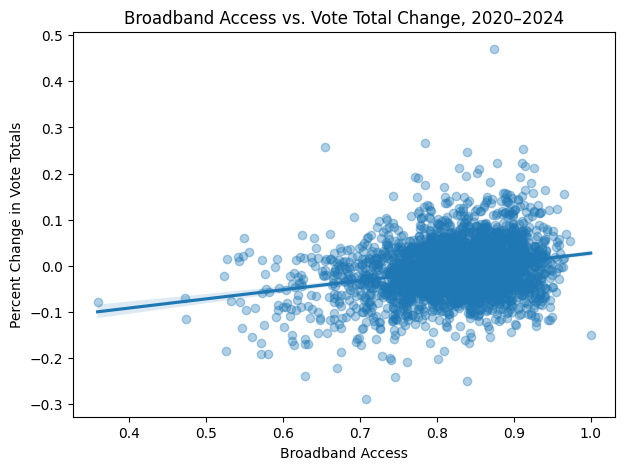

In [36]:
plt.figure(figsize=(7, 5))
sns.regplot(
    data=analysis_df,
    x='Broadband Access raw value',
    y='pct_change_2020_2024',
    scatter_kws={'alpha': 0.35}
)
plt.title("Broadband Access vs. Vote Total Change, 2020–2024")
plt.xlabel("Broadband Access")
plt.ylabel("Percent Change in Vote Totals")
plt.show()

# Population vs. Vote Change Scatter Plot
**Interpretation**

County population exhibits only a weak relationship with percent vote change.

Although larger counties contribute a greater number of total votes, the analysis focuses on percentage change rather than raw vote totals. As a result, population size alone does not strongly predict whether a county experienced growth or decline in voting activity.

This finding suggests that the factors influencing vote change are more closely related to socioeconomic characteristics and local conditions than to population size itself.

The weak relationship also indicates that both large and small counties experienced a wide range of voting outcomes between 2020 and 2024.

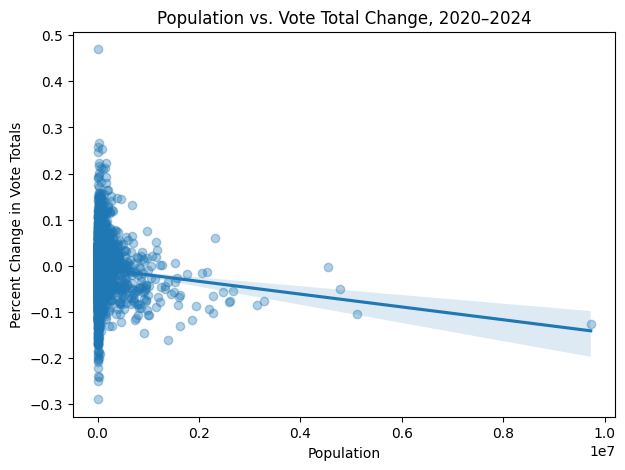

In [37]:
plt.figure(figsize=(7, 5))
sns.regplot(
    data=analysis_df,
    x='Population raw value',
    y='pct_change_2020_2024',
    scatter_kws={'alpha': 0.35}
)
plt.title("Population vs. Vote Total Change, 2020–2024")
plt.xlabel("Population")
plt.ylabel("Percent Change in Vote Totals")
plt.show()

# Regression Coefficients Chart
**Interpretation**

The regression model estimates the independent relationship between each county characteristic and vote change while controlling for the other variables in the model.

Positive coefficients indicate variables associated with higher vote growth, while negative coefficients indicate variables associated with vote decline.

Consistent with the correlation analysis, measures such as income, education, homeownership, and broadband access tend to contribute positively to vote change. Counties with higher levels of poverty tend to show negative associations with vote growth.

The relative size of the coefficients provides insight into which variables contribute the most explanatory power within the model. However, because many county characteristics are correlated with one another, the coefficients should be interpreted as associations rather than evidence of causation.

The model provides a useful exploratory framework for identifying patterns but does not fully explain why vote totals changed across counties between 2020 and 2024. Additional factors—including migration, voter registration trends, election laws, and local political conditions—likely account for much of the remaining variation.

14. Interpretable Regression Model
This model estimates which county characteristics are associated with percent change in vote totals between 2020 and 2024.

The model uses standardized features so that coefficients can be compared more easily.

This is an exploratory model. It is intended to identify associations, not to prove causation or make definitive predictions.

In [38]:
features = [
    'High School Completion raw value',
    'Some College raw value',
    'Median Household Income raw value',
    'Children in Poverty raw value',
    'Homeownership raw value',
    'Broadband Access raw value',
    '% Rural raw value',
    '% 65 and Older raw value',
    'Population raw value'
]

X = analysis_df[features]
y = analysis_df['pct_change_2020_2024']

valid_mask = y.notna() & np.isfinite(y)

X = X[valid_mask]
y = y[valid_mask]

X = X.fillna(X.median())

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())

X shape: (3114, 9)
y shape: (3114,)
Missing values in X: 0
Missing values in y: 0


In [40]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

model = LinearRegression()
model.fit(X_scaled, y)

y_pred = model.predict(X_scaled)

r2 = r2_score(y, y_pred)

print("Model R²:", r2)

Model R²: 0.18047040163902928


In [41]:
coef_df = pd.DataFrame({
    'Feature': features,
    'Standardized Coefficient': model.coef_
})

coef_df = coef_df.sort_values(
    'Standardized Coefficient',
    ascending=False
)

coef_df

,Feature,Standardized Coefficient
4,Homeownership raw value,0.010452
5,Broadband Access raw value,0.006104
0,High School Completion raw value,0.002923
2,Median Household Income raw value,0.000787
6,% Rural raw value,-0.001150
7,% 65 and Older raw value,-0.002198
8,Population raw value,-0.004638
1,Some College raw value,-0.009197
3,Children in Poverty raw value,-0.017799


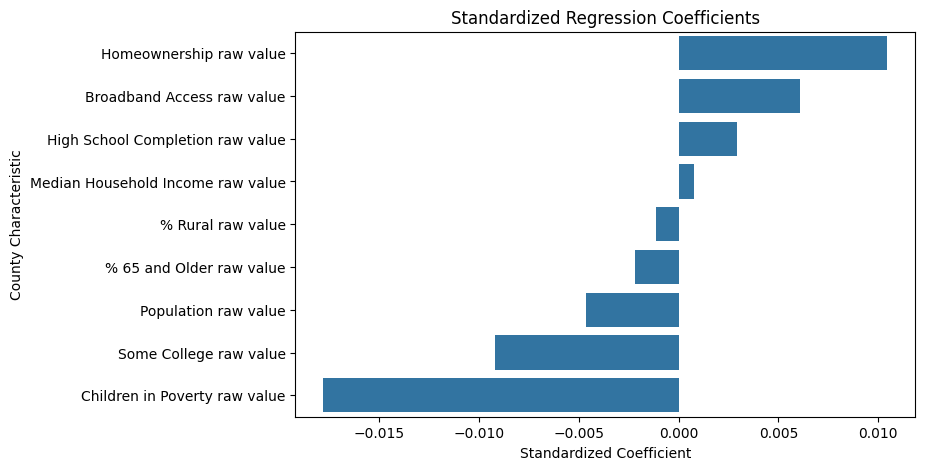

In [42]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=coef_df,
    x='Standardized Coefficient',
    y='Feature'
)
plt.title("Standardized Regression Coefficients")
plt.xlabel("Standardized Coefficient")
plt.ylabel("County Characteristic")
plt.show()

**The regression model explained 18% of the variation in county-level vote participation change between 2020 and 2024.**




In [43]:
from sklearn.metrics import r2_score

predictions = model.predict(X_scaled)

r2 = r2_score(y, predictions)

print(f"R²: {r2:.3f}")

R²: 0.180


**Model Performance**

The multiple linear regression model achieved an R² value of 0.18, indicating that approximately 18% of the variation in county-level voter participation change between 2020 and 2024 can be explained by the county characteristics included in this analysis.

The results suggest that factors such as homeownership, broadband access, educational attainment, and poverty are associated with changes in voter participation. However, a substantial portion of participation variation remains unexplained, indicating that additional demographic, political, economic, and election-specific factors likely influence county-level participation trends.

# 15. Questions

# 16. Limitations

# 17. Conclusion